### Packages

In [206]:
import sys
import numpy as np
import pandas as pd
import pathlib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from pprint import pprint
import yaml
from tqdm import tqdm

# notebook上で.pyファイルを設定しなおして、リロードする場合
import importlib

#- sys.modules に一度読み込まれたモジュールは、再度 import してもキャッシュから取得されます。
#- importlib.reload() はそのキャッシュを明示的に更新する方法
# .pyファイルのリロードする場合
#importlib.reload(ecg_reader)

#### Set Project Root Directory

In [207]:
#config.yamlを配置したフォルダをルートフォルダと設定する
def find_project_root(marker: str = "config.yaml") -> Path:
    path = Path.cwd()
    while not (path / marker).exists() and path != path.parent:
        path = path.parent
    return path

project_root = find_project_root()
print("RootDirectory Path:",project_root)

# system Pathに追加
sys.path.append(str(project_root))
#pprint(sys.path)
#project_root = Path.cwd().parent で設定するとuserName/projectsがparaentsフォルダ賭して認識されるため上記方法で固定とする

### フォルダ構成の確認
directory_file_list = list(project_root.glob("*"))
pprint(directory_file_list)

RootDirectory Path: /home/yohehe/projects/ECG-Analysis
[PosixPath('/home/yohehe/projects/ECG-Analysis/src'),
 PosixPath('/home/yohehe/projects/ECG-Analysis/MEMO.md'),
 PosixPath('/home/yohehe/projects/ECG-Analysis/README.md'),
 PosixPath('/home/yohehe/projects/ECG-Analysis/config.yaml'),
 PosixPath('/home/yohehe/projects/ECG-Analysis/.git'),
 PosixPath('/home/yohehe/projects/ECG-Analysis/notebooks'),
 PosixPath('/home/yohehe/projects/ECG-Analysis/analysis_test.ipynb')]


In [208]:
from src.data_utils.ecg_reader import load_table_as_pandas, load_ecg_metadata_by_id, extract_lead_features, plot_ecg_waveform
from src.system_utils import detect_os, windows_to_wsl_path, check_config_paths
from src.config_loader import DataConfig

### Set CONFIG

In [209]:
# OSを判定し、WSLの環境ではWindowsのディレクトリにアクセス可能なようにRootDirectoryを変更
detected_os = detect_os()
print("System Environment:", detected_os)

#wsl
set_root_directory = r"C:\Users\yohei\Desktop\physionet-ecg-image-digitization"
#mac
#set_root_directory = "/Users/yohe/Desktop/physionet-ecg-image-digitization"

if detected_os == "wsl":
    ECG_DATASET_ROOT = windows_to_wsl_path(set_root_directory)
else:
    ECG_DATASET_ROOT = Path(set_root_directory)

print("Project Root:", ECG_DATASET_ROOT)

System Environment: wsl
Project Root: /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization


In [210]:
# datareader用の設定
CONFIG = DataConfig(config_yaml_path=project_root/"config.yaml", 
                    root=ECG_DATASET_ROOT)
#CONFIGのパラメータを確認
pprint(CONFIG.__dict__)

# CONFIG内のパスが存在するか確認
check_config_paths(CONFIG)

{'sample_submission_csv_path': PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/sample_submission.parquet'),
 'test_csv_path': PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/test.csv'),
 'test_data_dir': PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/test'),
 'train_csv_path': PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train.csv'),
 'train_data_dir': PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train')}
すべてのパスが存在します


### read dataframe

In [211]:
train_df = load_table_as_pandas(path=CONFIG.train_csv_path, verbose=True)
test_df = load_table_as_pandas(path=CONFIG.test_csv_path, verbose=True)
sample_submission = load_table_as_pandas(path=CONFIG.sample_submission_csv_path, verbose=True)

Datatype is CSV
Datatype is CSV
Datatype is Parquet


In [212]:
### サンプルデータで出力テストをする

In [213]:
sample_id = 11842146
sample_data_dir = Path(CONFIG.train_data_dir / str(sample_id))
print("Sample Data Directory:", sample_data_dir)
list(sample_data_dir.glob("*"))

Sample Data Directory: /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146


[PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0001.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0003.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0004.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0005.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0006.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0009.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0010.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0011.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0012.png'),
 PosixPath('/mnt/c/Users/yoh

### CSVデータ処理

In [214]:
import neurokit2 as nk

In [215]:
### リードデータを抽出する
def extract_lead_signal(ecg_df: pd.DataFrame, lead: str = "I") -> np.ndarray:
    """
    指定されたリードの波形を抽出し、NaNを除去して返す。
    
    Parameters:
        ecg_df (pd.DataFrame): ECGの波形データ（CSV読み込み済み）
        lead (str): 抽出対象のリード名（例："I", "II", "V1"など）

    Returns:
        np.ndarray: NaN除去済みの波形データ
    """
    if lead not in ecg_df.columns:
        raise ValueError(f"リード '{lead}' は存在しません。利用可能なリード: {list(ecg_df.columns)}")

    signal = pd.to_numeric(ecg_df[lead], errors="coerce").dropna().values

    if len(signal) == 0:
        raise ValueError(f"リード '{lead}' に有効な波形データが存在しません。")

    return signal

In [216]:
sample_id = 11842146

# set directory
sample_data_dir = Path(CONFIG.train_data_dir / str(sample_id))
print("Sample Data Directory:", sample_data_dir)

# set csv data path
sample_csv_path = list(sample_data_dir.glob("*.csv"))[0]

ecg_df = pd.read_csv(sample_csv_path)
lead_signal = extract_lead_signal(ecg_df=ecg_df, lead="I")
print("信号長:", len(lead_signal))

Sample Data Directory: /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146
信号長: 2500


### 1. R peakの検出

In [217]:

def detect_r_peaks(signal: np.ndarray, fs: int = 1000) -> dict:
    """
    ECG波形からRピークを検出する関数（NeuroKit2使用）

    Parameters:
        signal (np.ndarray): NaN除去済みのECG波形
        fs (int): サンプリング周波数（Hz）

    Returns:
        dict: 以下のキーを含む辞書
            - "rpeaks": Rピーク位置（int型のnumpy配列）
            - "signals": NeuroKit2の信号構造
            - "info": Rピーク検出情報（辞書）
    """
    if len(signal) < 100:
        raise ValueError("信号が短すぎます。最低100サンプル以上必要です。")

    # Rピーク検出（NeuroKit2）
    signals, info = nk.ecg_peaks(signal, sampling_rate=fs)

    # Rピーク位置を整数型で抽出
    rpeaks = pd.Series(info["ECG_R_Peaks"]).dropna().astype(int).values

    return {
        "rpeaks": rpeaks,
        "signals": signals,
        "info": info
    }

In [218]:
#- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
#- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
signal = extract_lead_signal(ecg_df, lead="I")
print("shape of signal:",signal.shape)

r_result = detect_r_peaks(signal, fs=1000)
rpeaks = r_result["rpeaks"]
print("rpeaks:", rpeaks)
print("Rピーク数:", len(rpeaks))
print("Rピーク間隔:", np.diff(rpeaks))


shape of signal: (2500,)
rpeaks: [1050 1808]
Rピーク数: 2
Rピーク間隔: [758]


### P,QRS,Tを含めた検出
- 原因不明だが、ECG_R_Peaksが欠損する
- detect_ecg_waves_fixedで修正対応

In [282]:
def detect_ecg_waves(signal: np.ndarray, fs: int = 1000) -> dict:
    """
    ECG波形からP波・QRS波・T波のピーク位置を検出する関数

    Parameters:
        signal (np.ndarray): NaN除去済みのECG波形
        fs (int): サンプリング周波数（Hz）

    Returns:
        dict: 構成波のピーク位置（各波ごとにnp.ndarray）
    """
    if len(signal) < 100:
        raise ValueError("信号が短すぎます。最低100サンプル以上必要です。")

    # Rピーク検出
    signals, info = nk.ecg_peaks(signal, sampling_rate=fs)
    rpeaks = pd.Series(info["ECG_R_Peaks"]).dropna().astype(int).values
    print(rpeaks)

    # 構成波検出
    _, waves = nk.ecg_delineate(signal, rpeaks=rpeaks, sampling_rate=fs, method="dwt")

    # 各波のピーク位置を抽出
    wave_peaks = {}
    for wave in ["ECG_P_Peaks", "ECG_Q_Peaks", "ECG_R_Peaks", "ECG_S_Peaks", "ECG_T_Peaks"]:
        wave_peaks[wave] = pd.Series(waves.get(wave, [])).dropna().astype(int).values

    return wave_peaks

In [283]:
def detect_ecg_waves_fixed(signal: np.ndarray, fs: int = 1000) -> dict:
    """
    ECG波形からP波・QRS波・T波のピーク位置を検出する関数

    Parameters:
        signal (np.ndarray): NaN除去済みのECG波形
        fs (int): サンプリング周波数（Hz）

    Returns:
        dict: 構成波のピーク位置（各波ごとにnp.ndarray）
    """
    if len(signal) < 100:
        raise ValueError("信号が短すぎます。最低100サンプル以上必要です。")

    # Rピーク検出
    signals, info = nk.ecg_peaks(signal, sampling_rate=fs)
    rpeaks = pd.Series(info["ECG_R_Peaks"]).dropna().astype(int).values
    print(rpeaks)

    # 構成波検出
    _, waves = nk.ecg_delineate(signal, rpeaks=rpeaks, sampling_rate=fs, method="dwt")

    # 各波のピーク位置を抽出
    wave_peaks = {}
    for wave in ["ECG_P_Peaks", "ECG_Q_Peaks", "ECG_R_Peaks", "ECG_S_Peaks", "ECG_T_Peaks"]:
        wave_peaks[wave] = pd.Series(waves.get(wave, [])).dropna().astype(int).values

    # Rピークが空なら上書きする(この処理を入れないとECG_R_Peaksが空となる)
    if len(wave_peaks["ECG_R_Peaks"]) == 0:
        wave_peaks["ECG_R_Peaks"] = np.array(rpeaks)

    return wave_peaks


In [284]:
# plotを行う関数
def plot_ecg_waves(signal: np.ndarray, wave_peaks: dict, fs: int = 1000, title: str = "ECG Wave Delineation"):
    """
    ECG波形と構成波（P, Q, R, S, T）を色分けして可視化する関数

    Parameters:
        signal (np.ndarray): ECG波形
        wave_peaks (dict): detect_ecg_waves() の出力
        fs (int): サンプリング周波数（Hz）
        title (str): プロットタイトル
    """
    time_axis = np.arange(len(signal)) / fs
    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, signal, label="ECG Signal", color="black")

    wave_colors = {
        "ECG_P_Peaks": "blue",
        "ECG_Q_Peaks": "purple",
        "ECG_R_Peaks": "red",
        "ECG_S_Peaks": "orange",
        "ECG_T_Peaks": "green"
    }

    for wave, color in wave_colors.items():
        peaks = wave_peaks.get(wave, [])
        if isinstance(peaks, (np.ndarray, list)) and len(peaks) > 0:
            plt.scatter(time_axis[peaks], signal[peaks], color=color,
                        label=wave.replace("ECG_", "").replace("_Peaks", ""), s=40)

    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

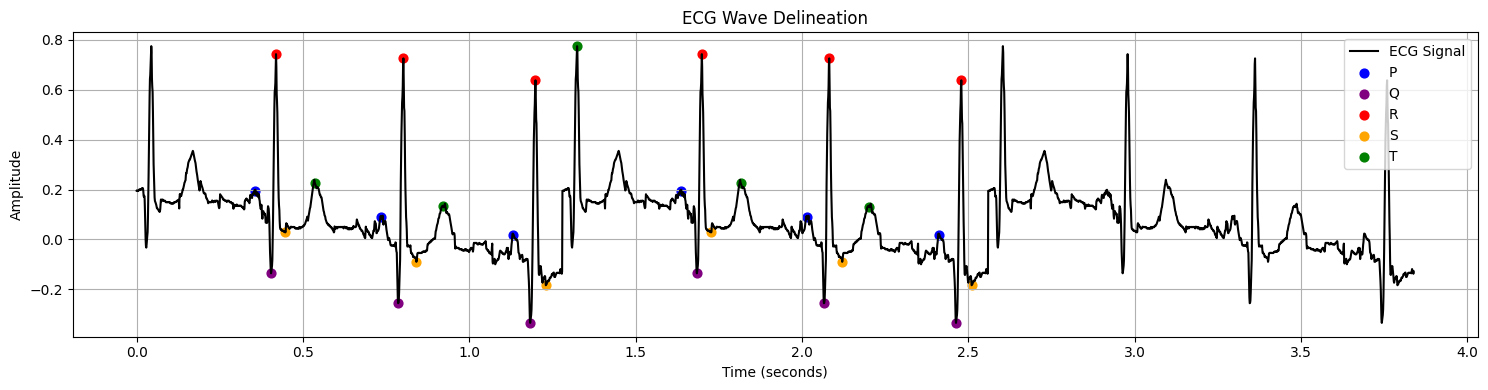

In [285]:
plot_ecg_waves(signal, result)

In [286]:
# freaquency sampling
random_choiced_id = train_df["id"].sample(1).values[0]
print(random_choiced_id)

1722454310


3848961967
Sample Data Directory: /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/3848961967
信号長: 625
[ 169  395  619  794 1020]
{'ECG_P_Peaks': array([125, 351, 584, 750, 976]), 'ECG_Q_Peaks': array([ 162,  387,  613,  787, 1012]), 'ECG_R_Peaks': array([ 169,  395,  619,  794, 1020]), 'ECG_S_Peaks': array([ 179,  403,  625,  804, 1028]), 'ECG_T_Peaks': array([ 231,  456,  653,  856, 1081])}


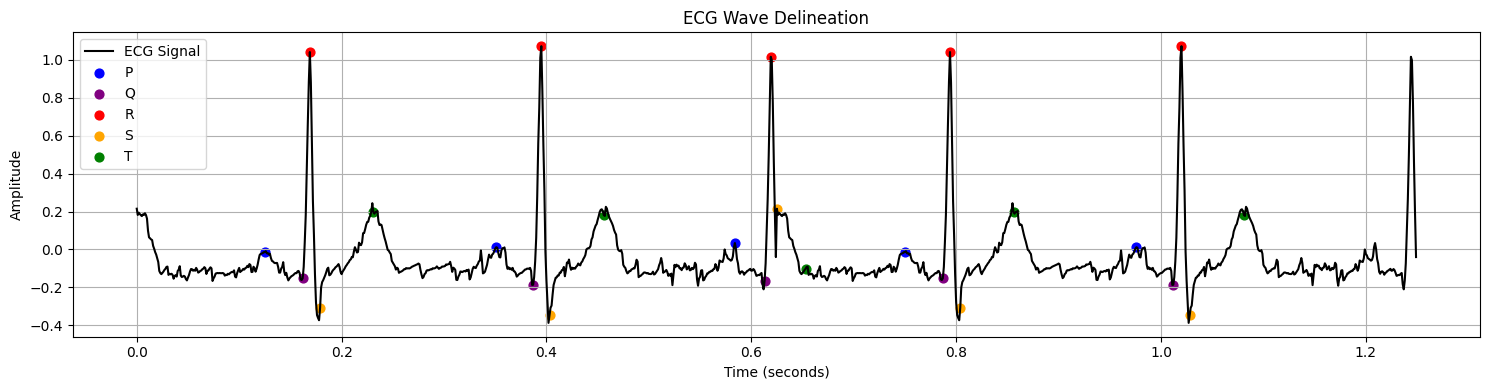

In [287]:
#sample_id = 11842146
# ランダムチェック
random_choiced_id = train_df["id"].sample(1).values[0]
print(random_choiced_id)

sample_id = random_choiced_id

# set directory
sample_data_dir = Path(CONFIG.train_data_dir / str(sample_id))
print("Sample Data Directory:", sample_data_dir)

# set csv data path
sample_csv_path = list(sample_data_dir.glob("*.csv"))[0]
ecg_df = pd.read_csv(sample_csv_path)
lead_signal = extract_lead_signal(ecg_df=ecg_df, lead="I")

# サンプリングレート：freaquency sampling
fs = train_df[train_df["id"]==sample_id]["fs"].values[0]


print("信号長:", len(lead_signal))
#- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
#- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
signal = extract_lead_signal(ecg_df, lead="I")
#無理やり結合
signal =np.tile(signal, 2)

result = detect_ecg_waves_fixed(signal, fs=fs)
print(result)
plot_ecg_waves(signal, result)

### ランダムなIDを選択して波形を確認

In [288]:
def check_extracted_peaks(id):

    '''
    - np.tileで無理やり結合している
    - 平滑化してない点に注意
    '''
    
    # set directory
    sample_data_dir = Path(CONFIG.train_data_dir / str(sample_id))
    print("Sample Data Directory:", sample_data_dir)

    # set csv data path
    sample_csv_path = list(sample_data_dir.glob("*.csv"))[0]
    ecg_df = pd.read_csv(sample_csv_path)
    lead_signal = extract_lead_signal(ecg_df=ecg_df, lead="I")
    
    # サンプリングレート：freaquency sampling
    fs = train_df[train_df["id"]==sample_id]["fs"].values[0]
    
    
    print("信号長:", len(lead_signal))
    #- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
    #- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
    signal = extract_lead_signal(ecg_df, lead="I")
    #無理やり結合
    signal =np.tile(signal, 3)
    
    result = detect_ecg_waves_fixed(signal, fs=fs)
    print(result)
    plot_ecg_waves(signal, result)

    return

In [289]:
# freaquency sampling
random_choiced_id = train_df["id"].sample(1).values[0]
print(random_choiced_id)

2567450244


Sample Data Directory: /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/3848961967
信号長: 625
[ 169  395  619  794 1020 1244 1419 1645]
{'ECG_P_Peaks': array([ 125,  351,  584,  750,  976, 1209, 1375, 1601]), 'ECG_Q_Peaks': array([ 148,  386,  612,  773, 1011, 1237, 1398, 1636]), 'ECG_R_Peaks': array([ 169,  395,  619,  794, 1020, 1244, 1419, 1645]), 'ECG_S_Peaks': array([ 178,  402,  624,  803, 1027, 1249, 1428, 1652]), 'ECG_T_Peaks': array([ 231,  456,  653,  856, 1081, 1278, 1481, 1706])}


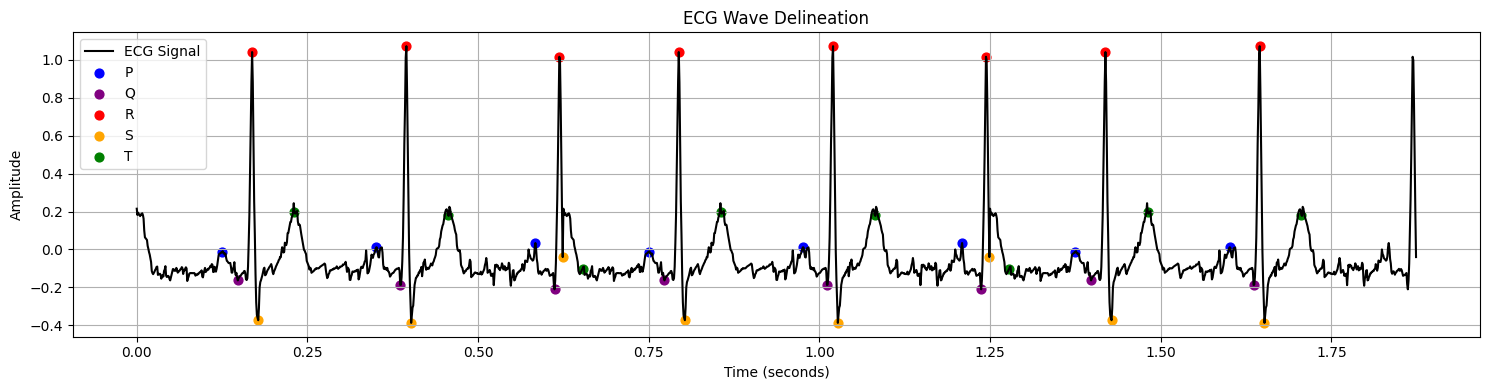

In [290]:
check_extracted_peaks(random_choiced_id)

### 上記に平滑化をかけて動作するかチェックする必要はありそう　

## 平滑化についてまとめる

# neurokitにある平滑化

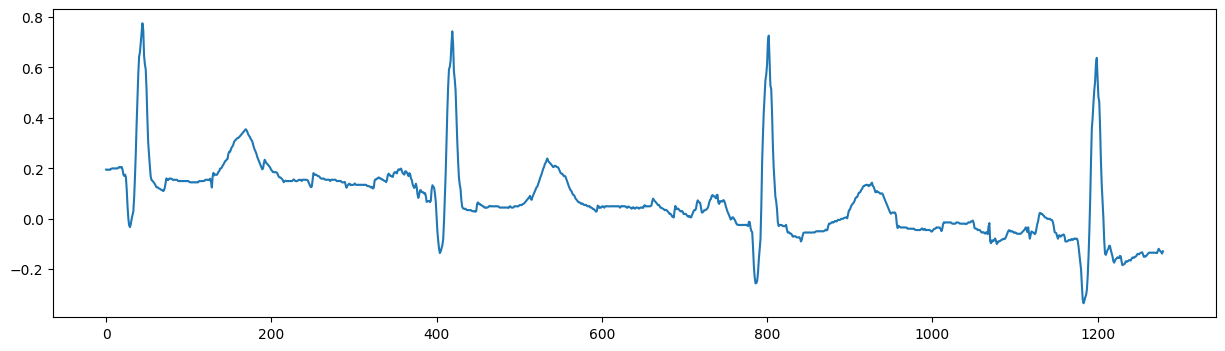

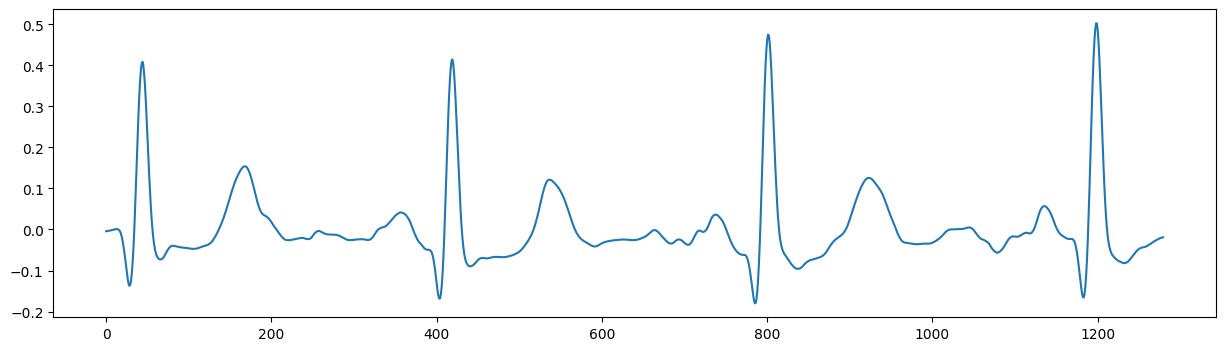

In [274]:
signal = extract_lead_signal(ecg_df, lead="I")
plt.figure(figsize=(15, 4))
plt.plot(signal)
signal = nk.ecg_clean(signal, sampling_rate=fs, method="neurokit")
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.show()

In [275]:
# 平滑化をかけた後での検出

In [276]:
#- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
#- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
signal = extract_lead_signal(ecg_df, lead="I")
#平滑化
fs =1000
signal = nk.ecg_clean(signal, sampling_rate=fs, method="neurokit")
#無理やり結合
signal =np.tile(signal, 3)

result = detect_ecg_waves(signal, fs=1000)
result

[ 420  802 1199 1700 2082 2479 2980 3362 3759]


ValueError: The data length is too small to be segmented.

### scipyを使用したもの

1. 🎛️ SciPyを使用した標準的なデジタルフィルタリング


PythonのSciPyライブラリは、フィルタ設計の標準的なツールです。ノイズの周波数帯域が明確な場合に、フィルタの特性（カットオフ周波数、次数）を細かく制御できます。

A. ベースラインドリフト除去 (ハイパスフィルタ)
低周波のベースライン変動を除去します。

In [89]:

from scipy.signal import butter, lfilter

def highpass_filter(signal: np.ndarray, cutoff_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """ハイパスフィルタ（バターワース）を適用し、ベースラインドリフトを除去する"""
    nyq = 0.5 * fs
    normal_cutoff = cutoff_hz / nyq
    
    # バターワースフィルタの係数を設計
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    
    # 信号にフィルタを適用 (双方向フィルタリングで位相歪みを回避)
    # lfilterの代わりにfiltfiltを使う方が、位相遅延を防げてECG解析では望ましい
    filtered_signal = lfilter(b, a, signal)
    
    return filtered_signal

# 使用例: 0.5 Hz以下の低周波ノイズを除去
# signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)

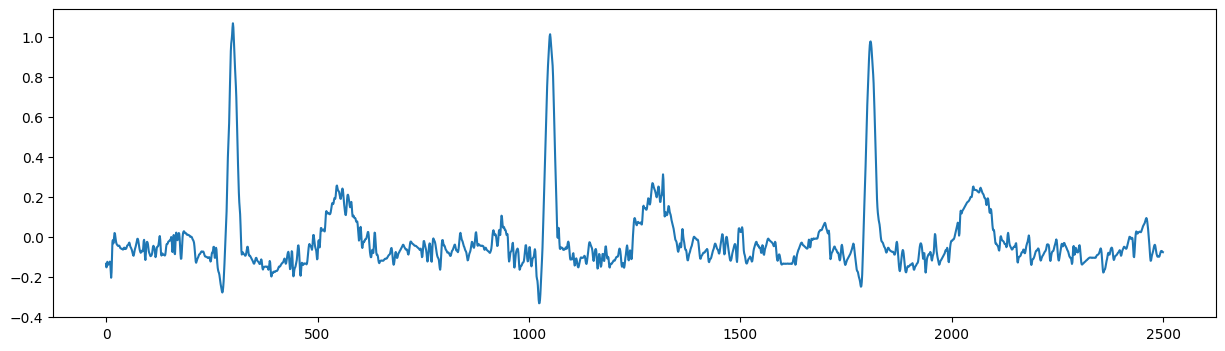

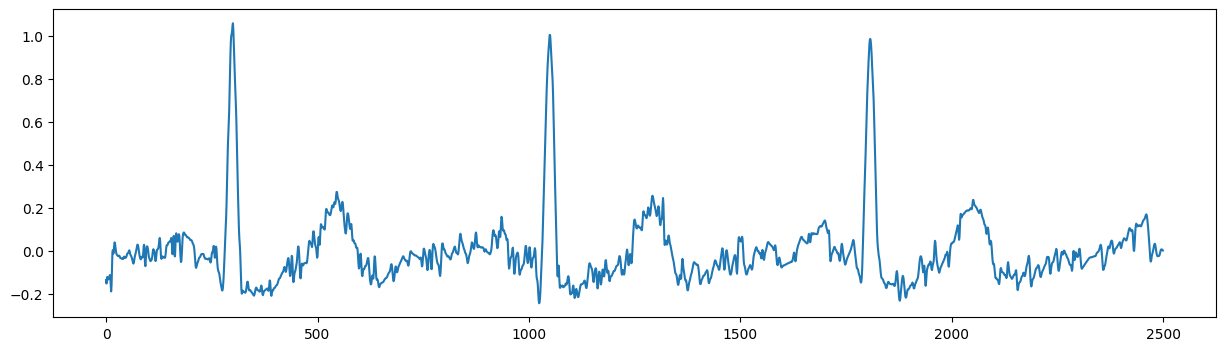

In [92]:
signal = extract_lead_signal(ecg_df, lead="I")
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.show()
signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)
plt.figure(figsize=(15, 4))
plt.plot(signal_filtered)
plt.show()

B. 高周波ノイズ除去 (ローパスフィルタ)

- 筋電図ノイズなどの高周波成分を除去し、波形を滑らかにします。

In [93]:
from scipy.signal import butter, lfilter

def lowpass_filter(signal: np.ndarray, cutoff_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """ローパスフィルタ（バターワース）を適用し、高周波ノイズを除去する"""
    nyq = 0.5 * fs
    normal_cutoff = cutoff_hz / nyq
    
    # バターワースフィルタの係数を設計
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # 信号にフィルタを適用 (双方向フィルタリングで位相歪みを回避)
    filtered_signal = lfilter(b, a, signal)
    
    return filtered_signal

# 使用例: 40 Hz以上の高周波ノイズを除去 (ECGでは一般的に使われるカットオフ)
# signal_smoothed = lowpass_filter(signal, cutoff_hz=40.0, fs=1000)

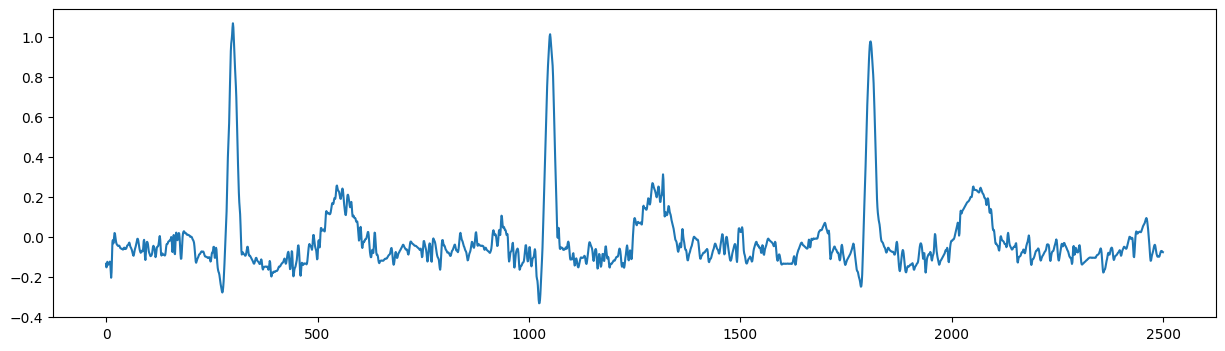

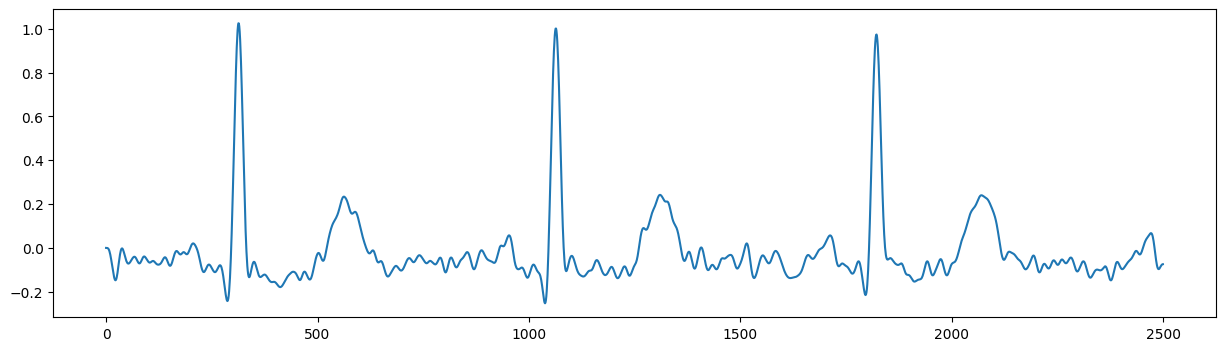

In [94]:
signal = extract_lead_signal(ecg_df, lead="I")
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.show()
#signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)
signal_smoothed = lowpass_filter(signal, cutoff_hz=40.0, fs=1000)
plt.figure(figsize=(15, 4))
plt.plot(signal_smoothed)
plt.show()

2. 🌊 ウェーブレット変換によるノイズ除去 (Denoising)

ウェーブレット変換は、時間と周波数の両方で信号を分析できるため、ノイズと信号成分を効果的に分離できます。これは特にP波やT波の微妙な形状を保持しつつノイズを除去したい場合に有効です。

ライブラリ: PyWavelets (pywt) が一般的に使われます。

In [95]:
import pywt

def wavelet_denoise(signal: np.ndarray, wavelet: str = 'db4', level: int = 3) -> np.ndarray:
    """ウェーブレット変換によるノイズ除去（平滑化）"""
    
    # ウェーブレット変換を実行
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    
    # 各レベルのノイズ閾値を計算（通常、中央値絶対偏差MADを使用）
    sigma = pywt.median_absolute_deviation(coeffs[-level])
    threshold = sigma * np.sqrt(2 * np.log(len(signal)))
    
    # ノイズ成分（詳細係数）に閾値処理を適用
    denoised_coeffs = []
    for i, coeff in enumerate(coeffs):
        if i == 0:
            # 近似係数はそのまま残す（低周波の信号成分）
            denoised_coeffs.append(coeff)
        else:
            # 詳細係数にソフト閾値処理を適用
            denoised_coeffs.append(pywt.threshold(coeff, threshold, mode='soft'))
            
    # 逆ウェーブレット変換で信号を再構成
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
    
    # NOTE: 長さが少し変わる場合があるため、元の長さに合わせてクリップまたはパディングが必要な場合がある
    return denoised_signal[:len(signal)]

# ウェーブレットノイズ除去は、実装が複雑になるため、nk.ecg_cleanが失敗する場合の高度な代替策として検討します。

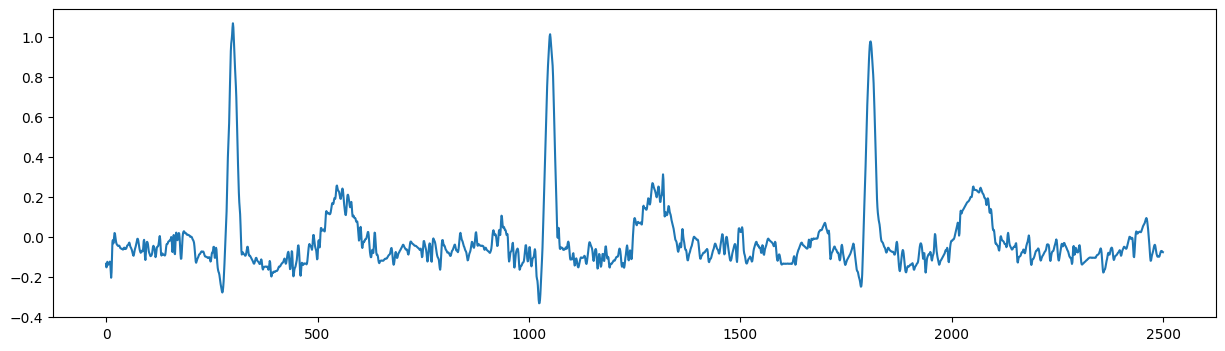

AttributeError: module 'pywt' has no attribute 'median_absolute_deviation'

In [96]:
signal = extract_lead_signal(ecg_df, lead="I")
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.show()
#signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)
signal_smoothed = wavelet_denoise(signal)
plt.figure(figsize=(15, 4))
plt.plot(signal_smoothed)
plt.show()

In [116]:
import numpy as np
from scipy.signal import butter, filtfilt
import pywt
from typing import Tuple

# --- SciPyによる標準的なデジタルフィルタリング（ECG解析推奨） ---

def butter_bandpass_filter(signal: np.ndarray, lowcut_hz: float, highcut_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """
    ECG信号にバターワース・バンドパスフィルタを適用し、ノイズとベースラインを除去する。
    
    Parameters:
        signal (np.ndarray): 処理対象の信号。
        lowcut_hz (float): ハイパスフィルタのカットオフ周波数（ベースライン除去）。通常 0.5 Hz。
        highcut_hz (float): ローパスフィルタのカットオフ周波数（高周波ノイズ除去）。通常 30-40 Hz。
        fs (int): サンプリング周波数（Hz）。
        order (int): フィルタの次数。

    Returns:
        np.ndarray: フィルタリングされた信号。
    """
    if fs <= highcut_hz * 2:
        print("警告: サンプリング周波数が低すぎます。フィルタリングスキップ。")
        return signal.copy()

    nyq = 0.5 * fs
    low = lowcut_hz / nyq
    high = highcut_hz / nyq
    
    # バンドパスフィルタの係数を設計
    b, a = butter(order, [low, high], btype='band', analog=False)
    
    # filtfiltを使用し、位相遅延のないフィルタリングを実行
    # NOTE: filtfiltを使用する場合、信号が短すぎるとエラーになる可能性があるため、信号長をチェック
    if len(signal) < 3 * order:
        raise ValueError(f"信号が短すぎます。filtfiltを使用するには信号長が {3*order} サンプル以上必要です。")
        
    filtered_signal = filtfilt(b, a, signal)
    
    return filtered_signal

# --- PyWaveletsによるウェーブレットノイズ除去（修正版） ---

def wavelet_denoise(signal: np.ndarray, wavelet: str = 'db4', level: int = 3) -> np.ndarray:
    """
    ウェーブレット変換によるノイズ除去（平滑化）。
    median_absolute_deviationのエラーに対応するため、NumPyでMADを計算するように修正済み。

    Parameters:
        signal (np.ndarray): 処理対象の信号。
        wavelet (str): 使用するウェーブレットファミリー。
        level (int): 分解レベル。

    Returns:
        np.ndarray: ノイズ除去された信号。
    """
    
    # 信号の長さが2のべき乗でない場合があるため、処理
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    
    # ノイズレベルの推定（MAD法：最も細かいスケール(coeffs[-1])の絶対値の中央値を使用）
    # 0.6745 は正規分布における定数で、標準偏差の推定に使用
    noise_estimate = np.median(np.abs(coeffs[-1])) / 0.6745
    
    # VisuShrink閾値を計算 (普遍的閾値)
    threshold = noise_estimate * np.sqrt(2 * np.log(len(signal)))
    
    denoised_coeffs = []
    for i, coeff in enumerate(coeffs):
        if i == 0:
            # 近似係数はそのまま残す
            denoised_coeffs.append(coeff)
        else:
            # 詳細係数にソフト閾値処理を適用
            denoised_coeffs.append(pywt.threshold(coeff, threshold, mode='soft'))
            
    # 逆ウェーブレット変換で信号を再構成
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)[:len(signal)]
    
    return denoised_signal



In [ ]:
# --- 使用例 ---
if __name__ == '__main__':
    fs = 1000
    #t = np.linspace(0, 5, 5*fs, endpoint=False)
    # ノイズとドリフトを含むモック信号
    #ecg_signal = np.sin(2 * np.pi * 1 * t) + np.random.normal(0, 0.2, 5000) + np.sin(2 * np.pi * 0.1 * t) * 0.5
    ecg_signal = extract_lead_signal(ecg_df, lead="I")
    print("--- フィルタリングテスト ---")

    # 1. SciPyによるバンドパスフィルタ（推奨）
    try:
        # ベースライン除去(0.5Hz以下)と高周波ノイズ除去(40Hz以上)を同時に実行
        scipy_filtered = butter_bandpass_filter(ecg_signal, lowcut_hz=0.5, highcut_hz=40.0, fs=fs)
        print("SciPy (Bandpass) フィルタリング成功。")
    except Exception as e:
        print(f"SciPyフィルタリングエラー: {e}")
        scipy_filtered = ecg_signal
        
    # 2. ウェーブレットノイズ除去（修正版）
    try:
        wavelet_filtered = wavelet_denoise(ecg_signal, wavelet='db4', level=4)
        print("Waveletノイズ除去成功。")
    except Exception as e:
        print(f"Waveletノイズ除去エラー: {e}")
        wavelet_filtered = ecg_signal
        
    print("フィルタリングされた信号が生成されました。これを次のステップ（safe_tile_signalなど）に使用できます。")

--- フィルタリングテスト ---
SciPy (Bandpass) フィルタリング成功。
Waveletノイズ除去成功。
フィルタリングされた信号が生成されました。これを次のステップ（safe_tile_signalなど）に使用できます。


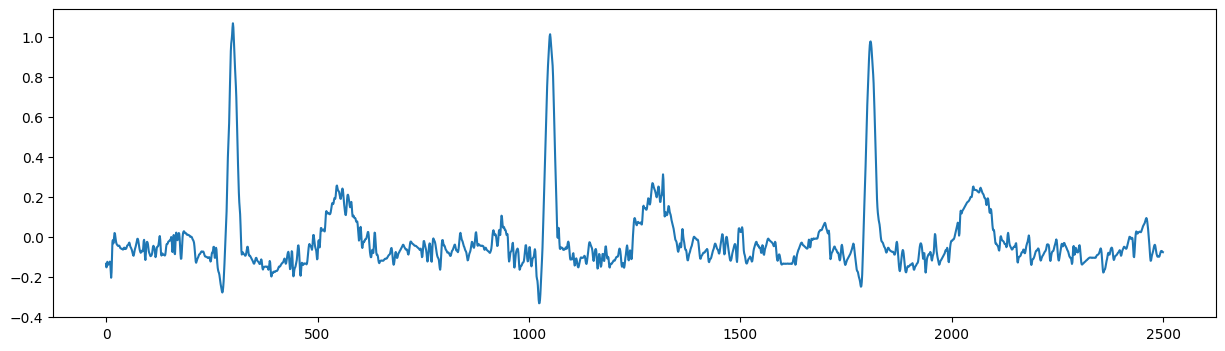

In [118]:
plt.figure(figsize=(15, 4)) 
plt.plot(ecg_signal)
plt.show()

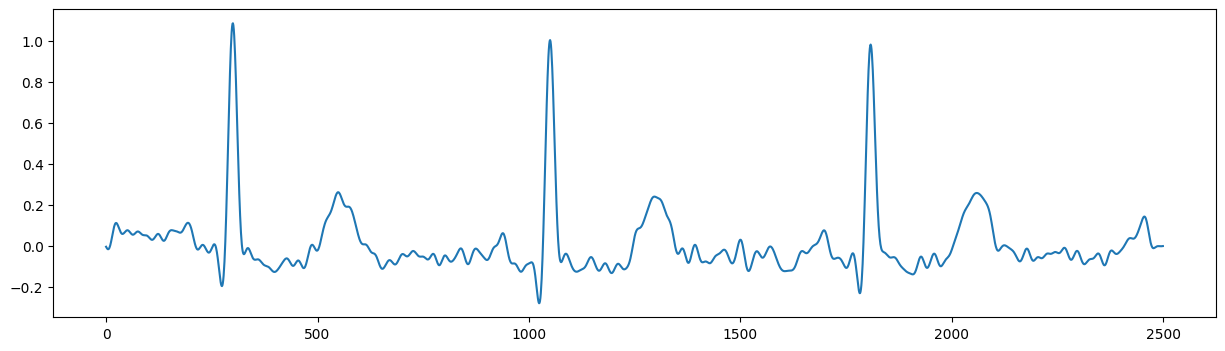

In [125]:
plt.figure(figsize=(15, 4)) 
plt.plot(scipy_filtered)

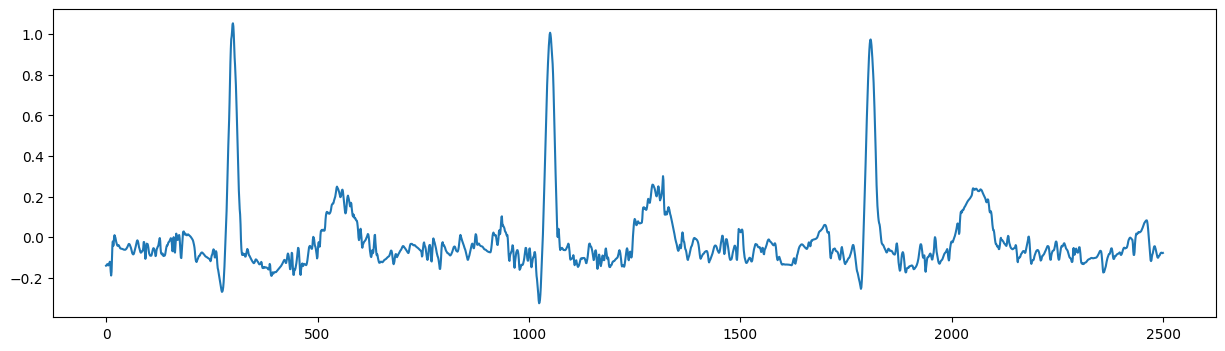

In [126]:
plt.figure(figsize=(15, 4)) 
plt.plot(wavelet_filtered)

### scipy filteringでの急激な立ち上がりについて

この問題は、ゼロ位相フィルタリング（scipy.signal.filtfilt）を使用した際に発生する**初期過渡応答（Start-up Transient）**と呼ばれる現象です。

🚨 Rピーク検出における初期過渡応答の問題点
filtfiltは、信号の位相をずらさずにフィルタリングするために順方向と逆方向に2回フィルタをかけますが、信号の最初と最後ではフィルタの初期条件が不安定になり、一時的に信号がオーバーシュートしたり急激に立ち上がったりします。

特にECGのベースライン除去（低周波カット）のようなフィルタでは、信号の最初の部分がフィルタの定常状態に達するまで時間がかかるため、このトランジェントが目立ちます。

💡 解決策：初期トランジェントの抑制と安定化
解決策は、「トランジェントを無視できるほど短くする」か、「信号の開始部分でトランジェントが発生しないようにパディングを工夫する」の2つです。

最も実用的な解決策として、以下の手法を提案します。

SOSフィルタリングの使用: filtfiltの代わりに、数値的に安定性が高いscipy.signal.sosfiltfiltを使用します。

パディングの強化: filtfilt系関数が内部で行うパディングを強化し、トランジェントを信号の先頭から押し出します。

以下の関数では、安定性の高いsosfiltfiltと、フィルタの次数に基づいて推奨されるパディング長（padlen=3*order）を適用します。

In [127]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from typing import Tuple

def butter_bandpass_filter(signal: np.ndarray, lowcut_hz: float, highcut_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """
    ECG信号にバターワース・バンドパスフィルタを適用する。
    scipy.signal.sosfiltfiltを使用することで、数値的安定性と初期トランジェントへの対応力を向上させる。

    Parameters:
        signal (np.ndarray): 処理対象の信号。
        lowcut_hz (float): ハイパスフィルタのカットオフ周波数（ベースライン除去）。通常 0.5 Hz。
        highcut_hz (float): ローパスフィルタのカットオフ周波数（高周波ノイズ除去）。通常 30-40 Hz。
        fs (int): サンプリング周波数（Hz）。
        order (int): フィルタの次数。

    Returns:
        np.ndarray: フィルタリングされた信号。
    """
    if fs <= highcut_hz * 2:
        print("警告: サンプリング周波数が低すぎます。フィルタリングスキップ。")
        return signal.copy()

    nyq = 0.5 * fs
    low = lowcut_hz / nyq
    high = highcut_hz / nyq
    
    # バターワースフィルタのセカンドオーダセクション（SOS）係数を設計
    # sosfiltfiltは、b, a係数ではなくsos係数を使用することで、数値的な丸め誤差を防ぐため推奨される
    sos = butter(order, [low, high], btype='band', analog=False, output='sos')
    
    # sosfiltfiltを使用し、位相遅延のないフィルタリングを実行
    # padlen='auto' (推奨) または padlen=3*order を使用して、トランジェントを抑制する
    
    # filtfilt系関数は信号長がパッド長*3未満だとエラーになる
    min_len = 3 * order
    if len(signal) < min_len:
        raise ValueError(f"信号が短すぎます。フィルタリングには最低 {min_len} サンプルが必要です。")
        
    # sosfiltfiltのpadtype='odd'はデフォルトで反射パディングを行い、トランジェント抑制を試みる
    filtered_signal = sosfiltfilt(sos, signal, padtype='odd', padlen=min_len)
    
    return filtered_signal

In [128]:
# ベースライン除去(0.5Hz以下)と高周波ノイズ除去(40Hz以上)を同時に実行
scipy_filtered = butter_bandpass_filter(ecg_signal, lowcut_hz=0.5, highcut_hz=40.0, fs=fs)
print("SciPy (Bandpass) フィルタリング成功。")

SciPy (Bandpass) フィルタリング成功。


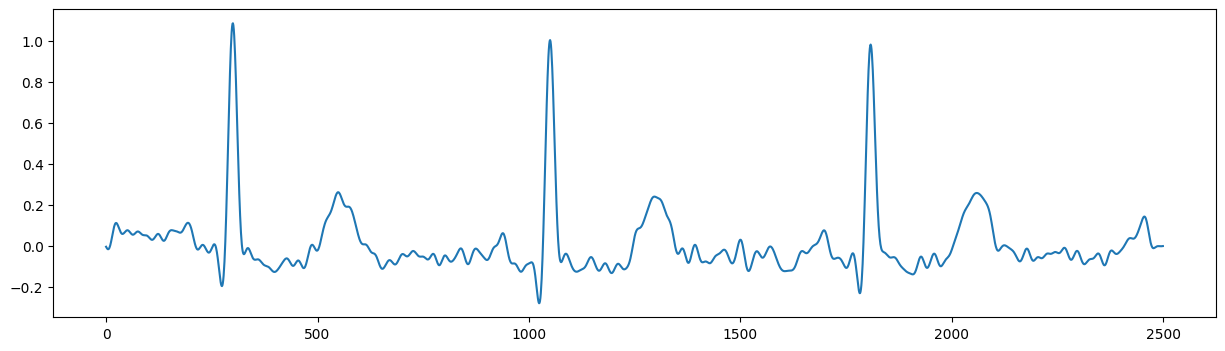

In [129]:
plt.figure(figsize=(15, 4)) 
plt.plot(scipy_filtered)

補足：それでも立ち上がりが気になる場合上記の修正版でトランジェントは改善されるはずですが、もしまだ最初の立ち上がりが急激すぎると感じる場合は、以下の方法を検討してください。信号のトリミング: フィルタリング後の信号の最初の数サンプルを物理的に削除します。ECG解析では、正確なピーク検出が必要なため、信号の最初から安定していることが理想です。フィルタの次数にもよりますが、最初の $3 \times \text{order}$ サンプルや、最初の 50ms（$0.05 \times \text{fs}$ サンプル）程度を無視して、残りの安定した部分のみを次のsafe_tile_signalに渡すことを検討してください。

In [ ]:
# 例：フィルタリング後の信号の最初の50サンプルを無視する
N_SKIP = int(0.05 * fs) 
stable_signal = scipy_filtered[N_SKIP:]

In [131]:
### 上記で解決できていそう
